In [ ]:
!pip install stable-baselines3==2.7.1
!pip install d3rlpy==2.8.1
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [ ]:
import collections
import random

import d3rlpy
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import stable_baselines3 as sb3
import torch


print("d3rlpy:", d3rlpy.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("stable baselines3:", sb3.__version__)
print("pytorch:", torch.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


d3rlpy: 2.8.1
gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
stable baselines3: 2.7.1
pytorch: 2.10.0+cu128


In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    DEVICE_STRING = "cuda:0"
else:
    DEVICE_STRING = "cpu"

In [ ]:
class MyInventoryEnv(gym.Env):
    def __init__(self, continuous_action_flag, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 行動が連続的かどうか(違う場合は離散的)のフラグ
        self.continuous_action_flag = continuous_action_flag
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # モデルがlearnやpredictメソッドの時に扱う行動(変数名はself.action_spaceがお作法)を定義
        if self.continuous_action_flag:  # 行動は連続値
            self.action_space = gym.spaces.Box(low=0,  # 発注量0～10を行動として、array形状を(1, )とする
                                               high=10,
                                               shape=(1, ),
                                               dtype=np.float32)
        else:  # 行動は離散値
            self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                    seed=42,
                                                    start=0,
                                                    dtype=np.int32)
        # モデルがlearnやpredictメソッドの時に扱う状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 行動が連続値の時は整数部分を取得、離散値の時はそのまま
        if self.continuous_action_flag:
            preprocessed_action = np.round(a=action[0],  # 形状は(1, )なので[0]で要素を取得して四捨五入する
                                           decimals=0)
        else:
            preprocessed_action = int(action)  # そのまま(念のためint型にする)
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(preprocessed_action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if preprocessed_action != 0:
            reward = reward - 0.5
        # 在庫量が0になった場合は在庫管理が適切でなかったとしてterminatedをtrueにしてtruncatedはfalseにする
        if self.state[0] == 0:
            terminated = True
            truncated = False  # ここでtruncatedをfalseにしてしまうのは、d3rlpyライブラリでは両方をtrueというのは許さない仕様のため
        else:  # 在庫量が0でない場合はterminatedをfalseにして、
            terminated = False
            # その時に、ステップ数が最大ステップ数の場合はtruncatedをtrueにする
            if self.current_step == self.max_step:
                truncated = True
            else:
                truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

In [ ]:
def collect_data_by_trained_actor(algorithm_name, env, model, timestep, deterministic_predict_flag, random_sampling_flag, random_sampling_ratio):
    state_list = []
    action_list = []
    reward_list = []
    terminated_list = []
    truncated_list = []
    state, _ = env.reset()
    for i in range(timestep):
        predicted_action, hidden = model.predict(observation=state,
                                                 deterministic=deterministic_predict_flag)
        if random_sampling_flag:  # ランダムサンプリングのフラグがTrueの場合は、
            if random.uniform(a=0, b=1.0) < random_sampling_ratio:  # 指定の確率で、
                predicted_action = env.action_space.sample()  # ランダムサンプリングの行動で上書きする
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        state_list.append(state)
        action_list.append(predicted_action)
        reward_list.append(reward)
        terminated_list.append(terminated)
        truncated_list.append(truncated)
        if terminated or truncated:
            state, _ = env.reset()
        else:
            state = next_state
    state_array = np.array(object=state_list,  # 形状は(timestep数, 3)
                           dtype=np.float32)
    action_array = np.array(object=action_list,
                            dtype=np.float32).reshape((-1, 1))  # 形状は(timestep数, 1)
    reward_array = np.array(object=reward_list,  # 形状は(timestep数, )
                            dtype=np.float32)
    terminated_array = np.array(object=terminated_list,  # 形状は(timestep数, )
                                dtype=np.float32)
    truncated_array = np.array(object=truncated_list,  # 形状は(timestep数, )
                               dtype=np.float32)
    return (state_array, action_array, reward_array, terminated_array, truncated_array)

In [ ]:
def inference_timestep(algorithm_name, env, model, timestep):
    state, _ = env.reset()
    reward = 0  # decision transformerの1ステップ目の推論で用いるため、0で初期化する
    total_reward = 0
    inventory_list = []
    available_inventory_list = []
    for i in range(timestep):
        print("{a}:{b}ステップ: 在庫量:{c} 翌納品:{d} 翌々納品(action):{e}".format(a=algorithm_name, b=i, c=state[0], d=state[1], e=state[2]))
        inventory_list.append(state[0])
        available_inventory_list.append(state[0]+state[1]+state[2])
        if algorithm_name in ["IQL", "CQL-SAC", "CQL-DDQN"]:
            state = state.reshape(1, -1)  # d3rlpyライブラリーのCQL系モデルは入力データにバッチ軸を求めるので、形状を(3, )から(1, 3)に変える
            # https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.predict
            predicted_action = model.predict(x=state)  # 出力の形状は(1, 1) # (入力したstateの時系列数, actionの次元数)
            predicted_action = predicted_action[0]  # [0]で取得して(1, )にする # env.stepでは行動の形状は(1, )を想定しているため
        elif algorithm_name in ["DecisionTransformer"]:
            # https://d3rlpy.readthedocs.io/en/stable/references/algos.html#decision-transformer
            # https://d3rlpy.readthedocs.io/en/v2.4.0/_modules/d3rlpy/algos/transformer/base.html
            predicted_action = model.predict(x=state,  # 出力の形状は(1, )
                                             reward=reward)
        else:
            # https://stable-baselines3.readthedocs.io/en/master/modules/sac.html#stable_baselines3.sac.SAC.predict
            predicted_action, hidden = model.predict(observation=state,
                                                     deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        total_reward = total_reward + reward
        if terminated or truncated:
            break
        state = next_state
    print("{a}:報酬合計:{b}".format(a=algorithm_name, b=total_reward))
    return inventory_list, available_inventory_list

In [ ]:
# 経験バッファにはSACで推論した行動のデータを保存するために、まずは環境からのデータを使ってSACを学習する
env_sac = MyInventoryEnv(continuous_action_flag=True,  # SACは連続的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
# https://stable-baselines3.readthedocs.io/en/master/modules/sac.html#stable_baselines3.sac.SAC
model_sac = sb3.SAC(policy="MlpPolicy",
                    env=env_sac,
                    learning_rate=0.0003,
                    buffer_size=2048,  # 経験バッファに保存するステップ数
                    learning_starts=64,  # 学習を開始する経験バッファ保存ステップ数
                    batch_size=64,
                    tau=0.005,  # ターゲットcriticのパラメータ更新を、criticのパラメータで行う割合
                    gamma=0.98,  # critic学習で正解データとなるターゲットQを算出する際の割引率
                    train_freq=1,  # 経験バッファにlearning_startsステップ数保存されて以降、何ステップ毎にactorとcriticの学習を行うか
                    ent_coef="auto",  # actor学習での損失値の算出や、critic学習でのターゲットQの算出にて、actorの推論による方策のエントロピー(ランダム性の尺度:−logπ(a∣s))を盛り込む割合(autoだと学習して動的な値になる)
                    target_update_interval=1,  # criticのパラメータ更新に伴って、ターゲットcriticを更新する間隔(1ならばcriticを学習するとターゲットcriticも学習する)
                    # verbose=1,
                    device=DEVICE)
model_sac.learn(total_timesteps=51200,
                progress_bar=True)

Output()

In [ ]:
datas_array = collect_data_by_trained_actor(algorithm_name="sac",  # 学習したSACによる推論の行動で経験バッファ用のデータを環境から収集する # SACの行動は連続的
                                            env=env_sac,
                                            model=model_sac,
                                            timestep=50000,  # 50000件のデータを収集する
                                            deterministic_predict_flag=True,  # Trueは決定的(最も高い確率になるμの行動)、Falseは確率的(μとσでの正規分布からのランダムサンプリング)
                                            random_sampling_flag=False,  # 一部の行動をランダムサンプリングにするかどうか
                                            random_sampling_ratio=0.1)  # ランダムサンプリングにする確率
dataset_decision_transformer = d3rlpy.dataset.MDPDataset(observations=datas_array[0],
                                                         actions=datas_array[1],
                                                         rewards=datas_array[2],
                                                         terminals=datas_array[3],
                                                         timeouts=datas_array[4])

2026-05-10 09:41.01 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-10 09:41.01 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-05-10 09:41.01 [info     ] Action size has been automatically determined. action_size=1


In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.DecisionTransformerConfig
model_config_decision_transformer = d3rlpy.algos.DecisionTransformerConfig(batch_size=256,
                                                                           gamma=1.0,  # d3rlpyライブラリではreturn-to-goを算出する際に将来の報酬に割引率を組み込んでる # 通常は割引率の影響を出さないため1.0にする
                                                                           context_size=31,  # transformerアーキテクチャーの入力データに用いられる時系列長
                                                                           max_timestep=31,  # positional encodingの際に用いる最大時系列長
                                                                           learning_rate=0.0001,
                                                                           num_heads=1,  # 自然言語処理では512次元ベクトル等で次元が多いのでヘッド数は8にしたりするけれど、深層強化学習では8に倣う必要はない
                                                                           num_layers=2,  # transformer層の数
                                                                           attn_dropout=0.1,  # self-attention層でのドロップアウト、具体的にはkeyやqueryやvalueのニューラルネットワークモデルでのドロップアウト
                                                                           resid_dropout=0.1,  # 残差接続の部分でのドロップアウト、具体的にはself-attention層やfeed-forward層の出力層部分のドロップアウト
                                                                           embed_dropout=0.1,  # embedding層でのドロップアウト
                                                                           activation_type="relu")  # feed-forward層での活性化関数
model_decision_transformer = model_config_decision_transformer.create(device=DEVICE_STRING)

In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.fit
model_decision_transformer.fit(dataset=dataset_decision_transformer,
                               n_steps=30000,
                               n_steps_per_epoch=1000,
                               with_timestamp=True,
                               show_progress=True)

2026-05-10 09:41.16 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-05-10 09:41.16 [debug    ] Building models...            
2026-05-10 09:41.16 [debug    ] Models have been built.       
2026-05-10 09:41.16 [info     ] Directory is created at d3rlpy_logs/DecisionTransformer_20260510094116
2026-05-10 09:41.16 [info     ] Parameters                     params={'observation_shape': [3], 'action_size': 1, 'config': {'type': 'decision_transformer', 'params': {'batch_size': 256, 'gamma': 1.0, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'context_size': 31, 'max_timestep': 31,

Epoch 1/30:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-05-10 09:43.07 [info     ] DecisionTransformer_20260510094116: epoch=1 step=1000 epoch=1 metrics={'time_sample_batch': 0.02366406011581421, 'time_algorithm_update': 0.08684714007377624, 'loss': 7.677101626396179, 'time_step': 0.1105962266921997} step=1000
2026-05-10 09:43.07 [info     ] Model parameters are saved to d3rlpy_logs/DecisionTransformer_20260510094116/model_1000.d3


Epoch 2/30:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-05-10 09:44.56 [info     ] DecisionTransformer_20260510094116: epoch=2 step=2000 epoch=2 metrics={'time_sample_batch': 0.02255119276046753, 'time_algorithm_update': 0.0853426353931427, 'loss': 7.610144673347473, 'time_step': 0.1079653925895691} step=2000
2026-05-10 09:44.56 [info     ] Model parameters are saved to d3rlpy_logs/DecisionTransformer_20260510094116/model_2000.d3


...

2026-05-10 10:32.21 [info     ] DecisionTransformer_20260510094116: epoch=28 step=28000 epoch=28 metrics={'time_sample_batch': 0.023429465770721435, 'time_algorithm_update': 0.08545672512054443, 'loss': 7.57921754360199, 'time_step': 0.10896611595153809} step=28000
2026-05-10 10:32.21 [info     ] Model parameters are saved to d3rlpy_logs/DecisionTransformer_20260510094116/model_28000.d3


Epoch 29/30:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-05-10 10:34.11 [info     ] DecisionTransformer_20260510094116: epoch=29 step=29000 epoch=29 metrics={'time_sample_batch': 0.023497124433517456, 'time_algorithm_update': 0.08538661289215088, 'loss': 7.569365451812744, 'time_step': 0.10896319365501404} step=29000
2026-05-10 10:34.11 [info     ] Model parameters are saved to d3rlpy_logs/DecisionTransformer_20260510094116/model_29000.d3


Epoch 30/30:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-05-10 10:36.01 [info     ] DecisionTransformer_20260510094116: epoch=30 step=30000 epoch=30 metrics={'time_sample_batch': 0.023501517057418823, 'time_algorithm_update': 0.08544319629669189, 'loss': 7.589192972660065, 'time_step': 0.10901851630210876} step=30000
2026-05-10 10:36.01 [info     ] Model parameters are saved to d3rlpy_logs/DecisionTransformer_20260510094116/model_30000.d3


DecisionTransformer:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
DecisionTransformer:1ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):1.0
DecisionTransformer:2ステップ: 在庫量:14.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:3ステップ: 在庫量:13.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:4ステップ: 在庫量:10.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:5ステップ: 在庫量:7.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:6ステップ: 在庫量:5.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:7ステップ: 在庫量:5.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:8ステップ: 在庫量:3.0 翌納品:1.0 翌々納品(action):1.0
DecisionTransformer:報酬合計:-6.199999809265137
SAC:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
SAC:1ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):3.0
SAC:2ステップ: 在庫量:14.0 翌納品:3.0 翌々納品(action):7.0
SAC:3ステップ: 在庫量:16.0 翌納品:7.0 翌々納品(action):0.0
SAC:4ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):0.0
SAC:5ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
SAC:6ステップ: 在庫量:12.0 翌納品:8.0 翌々納品(action):0.0
SAC:7ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):6.0
SAC:8ステップ: 在庫量:10.0 翌納品:6.0 翌々納品(action):0.0
SAC:9ス

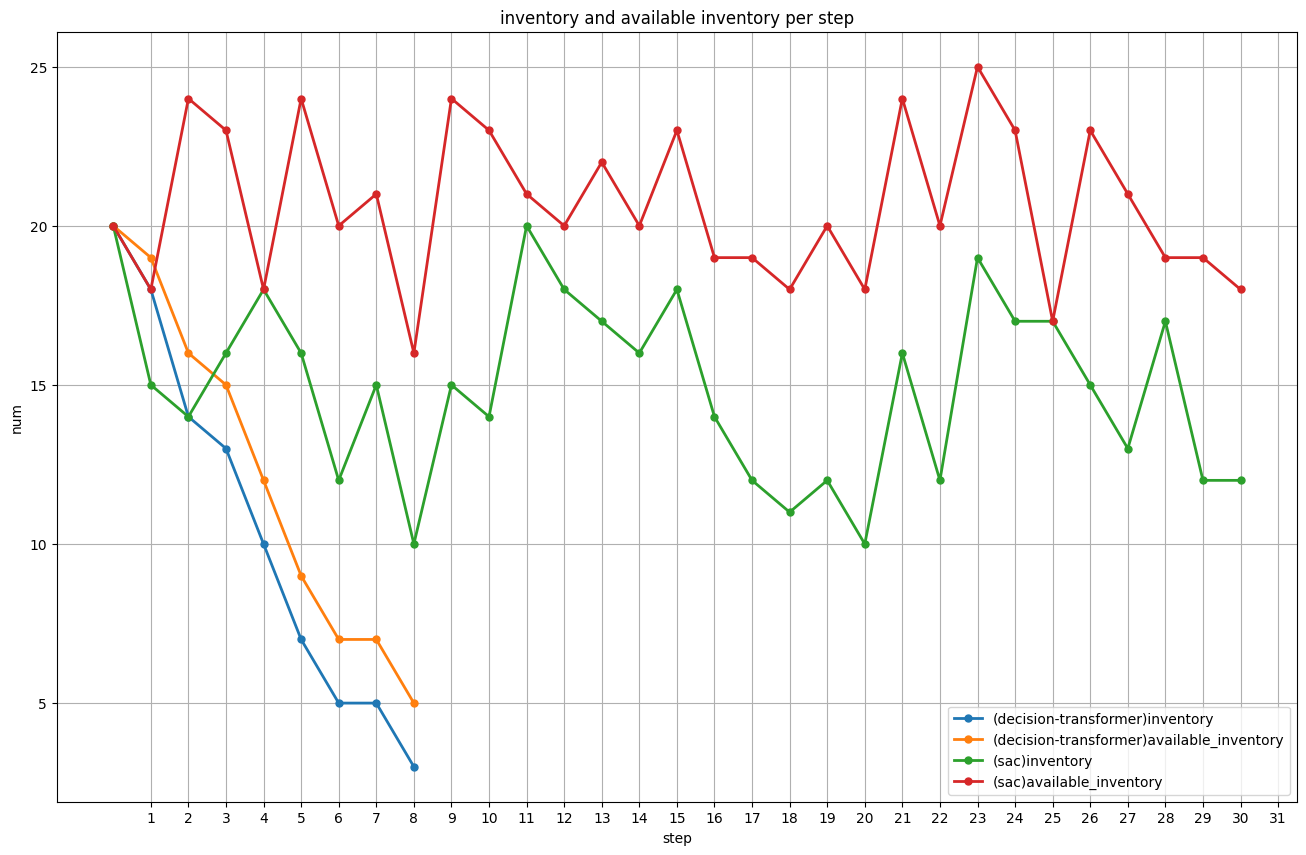

In [ ]:
env_decision_transformer = MyInventoryEnv(continuous_action_flag=True,
                                          initial_inventory=20,
                                          max_step=31,
                                          lead_time=2)
# https://d3rlpy.readthedocs.io/en/stable/references/algos.html#decision-transformer
model_decision_transformer_wrapper = model_decision_transformer.as_stateful_wrapper(target_return=15.0)  # predictメソッドで推論できるようにStatefulTransformerWrapperオブジェクトにする
inventory_list_decision_transformer, available_inventory_list_decision_transformer = inference_timestep(algorithm_name="DecisionTransformer",
                                                                                                        env=env_decision_transformer,
                                                                                                        model=model_decision_transformer_wrapper,
                                                                                                        timestep=31)
inventory_list_sac, available_inventory_list_sac = inference_timestep(algorithm_name="SAC",
                                                                      env=env_sac,
                                                                      model=model_sac,
                                                                      timestep=31)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(np.arange(stop=len(inventory_list_decision_transformer)),
         inventory_list_decision_transformer,
         label="(decision-transformer)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_decision_transformer)),
         available_inventory_list_decision_transformer,
         label="(decision-transformer)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(inventory_list_sac)),
         inventory_list_sac,
         label="(sac)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_sac)),
         available_inventory_list_sac,
         label="(sac)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="inventory and available inventory per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=np.arange(stop=len(inventory_list_sac))+1)
ax1.grid(True)
plt.show()

Decision TransformerでもCQL-DQNやCQL-SAC、IQLのような推論結果だった。<br>Decision Transformerならば価値関数のcriticに依存せずに、時系列予測のような形での推論、およびreturn-to-goという条件によってターゲットreturn-to-goを高めに設定して推論すれば正解データとなる経験バッファに保存されているデータでreturn-to-goの高いデータの行動に近いものを推論すると思われたがそうはならなかった。<br>このDecision Transformerは連続値での行動を推論する形であり、回帰タスクになっている。<br>つまり、損失関数は平均二乗誤差などであり、正解データとなる経験バッファには行動の値は多くが0であるため、推論では0もしくは1に近い値を平均的に出力する形で逃げれば損失値は低くなるとモデルは動いているのかもしれない。<br>では、推論する行動を離散値として分類タスクとするDecision Transformerにすれば、損失関数もクロスエントロピー誤差などになり、平均的な値を出力して逃げるという事も起きなくなるのではないか。